# Step 02 — Data Cleaning & NLP Preprocessing

## Détection des maladies mentales à partir des commentaires des réseaux sociaux

Ce notebook est la continuité directe du **Step 01 — Data Understanding & EDA**.

L'objectif n'est pas de nettoyer le texte au hasard, mais de choisir un preprocessing adapté aux anomalies observées :

- déséquilibre des classes ;
- textes vides, courts ou invalides ;
- bruit social media : URLs, mentions, hashtags ;
- emojis et symboles émotionnels ;
- caractères Unicode mal encodés ;
- slang et langage informel ;
- répétitions et caractères allongés ;
- ponctuation excessive ;
- stopwords sensibles, surtout les négations ;
- doublons exacts et doublons normalisés.

À la fin, on obtient un dataset propre avec une colonne finale `clean_text`, prêt pour la vectorisation et la modélisation.


## 0. Installation optionnelle des librairies


- `ftfy` : corriger certains problèmes Unicode.
- `emoji` : transformer les emojis en mots.
- `nltk` : lemmatisation optionnelle.


In [1]:
!pip install ftfy emoji nltk

## 1. Initialisation

Cette cellule  charge les librairies, définit les colonnes principales et prépare les options de nettoyage.


In [2]:

import os
import re
import string
import warnings
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Colonnes du dataset
TEXT_COL = "statement"
LABEL_COL = "status"

# Options de nettoyage guidées par l'EDA
REMOVE_EMPTY_TEXTS = True
REMOVE_MISSING_LABELS = True
REMOVE_DUPLICATES = True
FIX_UNICODE = True
REMOVE_URLS = True
REMOVE_MENTIONS = True
KEEP_HASHTAG_WORDS = True
CONVERT_EMOJIS_TO_TEXT = True
NORMALIZE_SLANG = True
NORMALIZE_ELONGATED_WORDS = True
NORMALIZE_REPEATED_PUNCTUATION = True
LOWERCASE = True
REMOVE_SPECIAL_CHARS = True
REMOVE_STOPWORDS = True
APPLY_LEMMATIZATION = False  # On garde False au début pour éviter un preprocessing trop agressif.

print("Initialisation terminée.")


Initialisation terminée.


## 2. Chargement du dataset





In [3]:

df = pd.read_csv("data.csv")

print("Dimensions initiales :", df.shape)
print("Colonnes :", df.columns.tolist())
display(df.head())


Dimensions initiales : (53043, 3)
Colonnes : ['Unnamed: 0', 'statement', 'status']


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


## 3. Vérification minimale des colonnes

Avant le nettoyage, on vérifie que les colonnes nécessaires existent bien.


In [4]:

required_columns = [TEXT_COL, LABEL_COL]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Colonnes manquantes : {missing_columns}. Vérifiez TEXT_COL et LABEL_COL.")

print("Colonnes texte et label validées.")


Colonnes texte et label validées.


## 4. Copie de travail et état initial

On conserve `df` comme version originale et on travaille sur `df_clean`.


In [5]:

df_clean = df.copy()

initial_rows = df_clean.shape[0]

print("Nombre de lignes initial :", initial_rows)
print("Nombre de colonnes initial :", df_clean.shape[1])


Nombre de lignes initial : 53043
Nombre de colonnes initial : 3


## 5. Diagnostic rapide avant nettoyage

Cette cellule reprend les principaux problèmes identifiés pendant l'EDA pour garder une trace avant correction.


In [6]:

df_clean[TEXT_COL] = df_clean[TEXT_COL].fillna("").astype(str)
df_clean["text_raw"] = df_clean[TEXT_COL]
df_clean["text_stripped"] = df_clean[TEXT_COL].str.strip()

initial_report = {
    "lignes_initiales": len(df_clean),
    "labels_manquants": int(df_clean[LABEL_COL].isna().sum()),
    "textes_vides": int(df_clean["text_stripped"].eq("").sum()),
    "doublons_exacts_texte": int(df_clean.duplicated(subset=[TEXT_COL]).sum()),
    "longueur_moyenne_mots": round(df_clean["text_stripped"].apply(lambda x: len(x.split())).mean(), 2),
}

pd.DataFrame(initial_report.items(), columns=["problème observé", "valeur"])


,problème observé,valeur
0,lignes_initiales,53043.00
1,labels_manquants,0.00
2,textes_vides,362.00
3,doublons_exacts_texte,1969.00
4,longueur_moyenne_mots,112.39


## 6. Suppression des labels manquants

### Problème EDA
Une ligne sans label ne peut pas être utilisée pour un apprentissage supervisé.

### Décision
On supprime les lignes dont la classe cible est manquante.


In [7]:

if REMOVE_MISSING_LABELS:
    before = len(df_clean)
    df_clean = df_clean.dropna(subset=[LABEL_COL]).copy()
    after = len(df_clean)
    print(f"Lignes supprimées pour label manquant : {before - after}")
else:
    print("Suppression des labels manquants désactivée.")


Lignes supprimées pour label manquant : 0


## 7. Suppression des textes vides ou invalides

### Problème EDA
Les textes vides ou uniquement composés d'espaces ne contiennent aucun signal lexical.

### Décision
On supprime uniquement les textes réellement vides. Les textes très courts ne sont pas supprimés automatiquement, 
car des phrases comme `help me` ou `kill me` peuvent être très importantes en santé mentale.


In [8]:

df_clean[TEXT_COL] = df_clean[TEXT_COL].fillna("").astype(str)
df_clean["text_stripped"] = df_clean[TEXT_COL].str.strip()

invalid_values = ["", "nan", "none", "null"]

if REMOVE_EMPTY_TEXTS:
    before = len(df_clean)
    df_clean = df_clean[~df_clean["text_stripped"].str.lower().isin(invalid_values)].copy()
    after = len(df_clean)
    print(f"Textes vides/invalides supprimés : {before - after}")
else:
    print("Suppression des textes vides désactivée.")


Textes vides/invalides supprimés : 362


## 8. Fonctions de nettoyage choisies à partir de l'EDA

Chaque fonction correspond à un problème repéré pendant le data understanding.


In [9]:

# Correction Unicode
try:
    import ftfy
except ImportError:
    ftfy = None

# Conversion emojis
try:
    import emoji
except ImportError:
    emoji = None

# Stopwords sklearn comme base, puis on conserve les négations importantes
try:
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    base_stop_words = set(ENGLISH_STOP_WORDS)
except Exception:
    base_stop_words = set()

negation_words = {
    "no", "not", "nor", "never", "none", "nothing", "nowhere", "neither",
    "cannot", "can't", "dont", "don't", "didnt", "didn't", "doesnt", "doesn't",
    "isnt", "isn't", "wasnt", "wasn't", "werent", "weren't", "wont", "won't",
    "wouldnt", "wouldn't", "shouldnt", "shouldn't", "couldnt", "couldn't"
}

safe_stop_words = base_stop_words - negation_words

slang_dict = {
    "u": "you",
    "ur": "your",
    "ya": "you",
    "idk": "i do not know",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "btw": "by the way",
    "brb": "be right back",
    "lol": "laughing",
    "lmao": "laughing",
    "omg": "oh my god",
    "tf": "the fuck",
    "wtf": "what the fuck",
    "rn": "right now",
    "tho": "though",
    "thx": "thanks",
    "pls": "please",
    "plz": "please",
    "bc": "because",
    "bcz": "because",
    "cuz": "because",
    "gonna": "going to",
    "wanna": "want to",
    "gotta": "got to",
    "kinda": "kind of",
    "sorta": "sort of"
}

contraction_dict = {
    "i'm": "i am",
    "i've": "i have",
    "i'll": "i will",
    "i'd": "i would",
    "you're": "you are",
    "you've": "you have",
    "he's": "he is",
    "she's": "she is",
    "it's": "it is",
    "we're": "we are",
    "they're": "they are",
    "can't": "cannot",
    "won't": "will not",
    "don't": "do not",
    "didn't": "did not",
    "doesn't": "does not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "shouldn't": "should not",
    "wouldn't": "would not",
    "couldn't": "could not"
}

url_pattern = re.compile(r"https?://\S+|www\.\S+")
mention_pattern = re.compile(r"@\w+")
hashtag_pattern = re.compile(r"#(\w+)")
html_pattern = re.compile(r"<.*?>")


def fix_unicode_text(text):
    if ftfy is not None:
        return ftfy.fix_text(text)
    return text


def convert_emojis(text):
    if emoji is not None:
        text = emoji.demojize(text, delimiters=(" ", " "))
        text = text.replace(":", " ").replace("_", " ")
    return text


def expand_contractions(text):
    words = text.split()
    expanded = [contraction_dict.get(word, word) for word in words]
    return " ".join(expanded)


def normalize_slang_text(text):
    words = text.split()
    normalized = [slang_dict.get(word, word) for word in words]
    return " ".join(normalized)


def reduce_elongated_words(text):
    # Exemple : sooooo -> soo ; nooooo -> noo
    return re.sub(r"(\w)\1{2,}", r"\1\1", text)


def reduce_repeated_punctuation(text):
    text = re.sub(r"!{2,}", "!", text)
    text = re.sub(r"\?{2,}", "?", text)
    text = re.sub(r"\.{3,}", "...", text)
    return text


def remove_special_characters(text):
    # On garde lettres, chiffres, espaces, apostrophes, ! et ? car ils peuvent signaler une intensité émotionnelle.
    text = re.sub(r"[^a-zA-Z0-9\s'!?]", " ", text)
    return text


def remove_stopwords_safe(text):
    words = text.split()
    words = [w for w in words if w not in safe_stop_words]
    return " ".join(words)


def basic_token_cleanup(text):
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Fonctions de nettoyage prêtes.")


Fonctions de nettoyage prêtes.


## 9. Fonction complète de preprocessing

Cette fonction applique les décisions retenues à partir de l'EDA.

Elle garde une logique modérée : on nettoie le bruit, mais on évite de supprimer les signaux émotionnels utiles.


In [10]:

def clean_text(text):
    text = str(text)

    if FIX_UNICODE:
        text = fix_unicode_text(text)

    text = html_pattern.sub(" ", text)

    if LOWERCASE:
        text = text.lower()

    text = expand_contractions(text)

    if REMOVE_URLS:
        text = url_pattern.sub(" URL ", text)
        text = text.replace(" URL ", " ")

    if REMOVE_MENTIONS:
        text = mention_pattern.sub(" ", text)

    if KEEP_HASHTAG_WORDS:
        text = hashtag_pattern.sub(r"\1", text)
    else:
        text = hashtag_pattern.sub(" ", text)

    if CONVERT_EMOJIS_TO_TEXT:
        text = convert_emojis(text)

    if NORMALIZE_SLANG:
        text = normalize_slang_text(text)

    if NORMALIZE_ELONGATED_WORDS:
        text = reduce_elongated_words(text)

    if NORMALIZE_REPEATED_PUNCTUATION:
        text = reduce_repeated_punctuation(text)

    if REMOVE_SPECIAL_CHARS:
        text = remove_special_characters(text)

    text = basic_token_cleanup(text)

    if REMOVE_STOPWORDS:
        text = remove_stopwords_safe(text)
        text = basic_token_cleanup(text)

    return text


## 10. Test du preprocessing sur quelques exemples

Avant d'appliquer le nettoyage sur tout le dataset, on vérifie le comportement sur des exemples typiques.


In [11]:

examples = [
    "I am soooo tired 😭😭 I don't know what to do!!!",
    "Check this link https://example.com @user #depression",
    "idk why I feel like this rn...",
    "emotion? ?! emotion. . emotion ?? HARU â™¡ ...",
    "I am not happy but I am trying."
]

for ex in examples:
    print("AVANT :", ex)
    print("APRÈS :", clean_text(ex))
    print("-" * 80)


AVANT : I am soooo tired 😭😭 I don't know what to do!!!
APRÈS : soo tired loudly crying face loudly crying face not know do!
--------------------------------------------------------------------------------
AVANT : Check this link https://example.com @user #depression
APRÈS : check link depression
--------------------------------------------------------------------------------
AVANT : idk why I feel like this rn...
APRÈS : not know feel like rn
--------------------------------------------------------------------------------
AVANT : emotion? ?! emotion. . emotion ?? HARU â™¡ ...
APRÈS : emotion? ?! emotion emotion ? haru
--------------------------------------------------------------------------------
AVANT : I am not happy but I am trying.
APRÈS : not happy trying
--------------------------------------------------------------------------------


## 11. Application du nettoyage au dataset

On crée une nouvelle colonne `clean_text` sans écraser le texte original.


In [12]:

df_clean["clean_text"] = df_clean[TEXT_COL].apply(clean_text)

display(df_clean[[TEXT_COL, "clean_text", LABEL_COL]].head(10))


,statement,clean_text,status
0,oh my gosh,oh gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...,Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",wrong dear forward doubt stay restless restles...,Anxiety
3,I've shifted my focus to something else but I'...,shifted focus worried,Anxiety
4,"I'm restless and restless, it's been a month n...",restless restless month boy mean?,Anxiety
5,"every break, you must be nervous, like somethi...",break nervous like wrong heck,Anxiety
6,"I feel scared, anxious, what can I do? And may...",feel scared anxious do? family protected,Anxiety
7,Have you ever felt nervous but didn't know why?,felt nervous did not know why?,Anxiety
8,"I haven't slept well for 2 days, it's like I'm...",haven't slept 2 days like restless huh,Anxiety
9,"I'm really worried, I want to cry.",really worried want,Anxiety


## 12. Analyse avant/après nettoyage

On compare la longueur des textes avant et après preprocessing.


,raw_num_words,clean_num_words
count,52681.00,52681.00
mean,113.16,48.26
std,163.74,68.16
min,1.00,0.00
25%,15.00,8.00
50%,62.00,27.00
75%,148.00,63.00
max,6300.00,2520.00


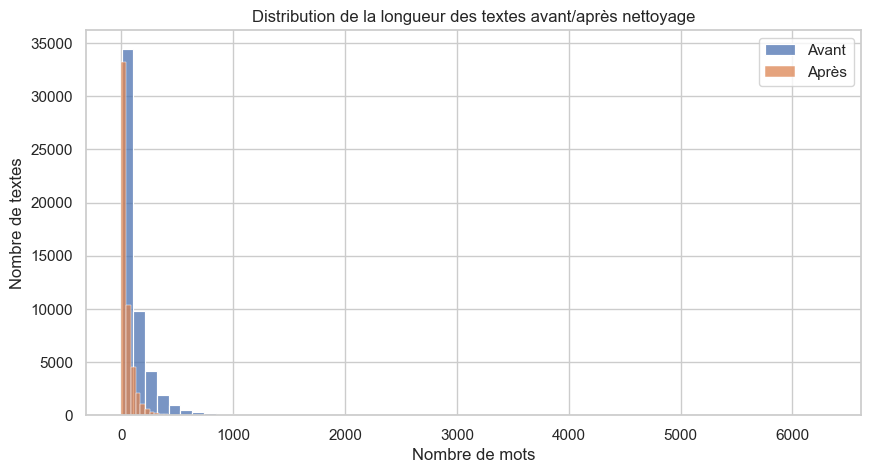

In [13]:

df_clean["raw_num_words"] = df_clean[TEXT_COL].fillna("").astype(str).apply(lambda x: len(x.split()))
df_clean["clean_num_words"] = df_clean["clean_text"].fillna("").astype(str).apply(lambda x: len(x.split()))

display(df_clean[["raw_num_words", "clean_num_words"]].describe().round(2))

plt.figure(figsize=(10, 5))
sns.histplot(df_clean["raw_num_words"], bins=60, label="Avant", kde=False)
sns.histplot(df_clean["clean_num_words"], bins=60, label="Après", kde=False)
plt.title("Distribution de la longueur des textes avant/après nettoyage")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de textes")
plt.legend()
plt.show()


## 13. Suppression des textes devenus vides après nettoyage

### Problème possible
Certains textes peuvent devenir vides après suppression des URLs, mentions, symboles ou stopwords.

### Décision
On les supprime, car ils ne contiennent plus de signal lexical exploitable.


In [14]:

before = len(df_clean)
df_clean = df_clean[df_clean["clean_text"].str.strip().ne("")].copy()
after = len(df_clean)

print("Textes supprimés car vides après nettoyage :", before - after)
print("Dimensions après suppression :", df_clean.shape)


Textes supprimés car vides après nettoyage : 73
Dimensions après suppression : (52608, 8)


## 14. Gestion des doublons

### Problème EDA
Les doublons peuvent donner au modèle une impression artificielle de performance, surtout si le même texte apparaît dans train et test.

### Décision
On supprime les doublons basés sur le texte nettoyé.


In [15]:

if REMOVE_DUPLICATES:
    before = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=["clean_text", LABEL_COL]).copy()
    after = len(df_clean)
    print("Doublons supprimés après nettoyage :", before - after)
else:
    print("Suppression des doublons désactivée.")

print("Dimensions actuelles :", df_clean.shape)


Doublons supprimés après nettoyage : 2002
Dimensions actuelles : (50606, 8)


## 15. Vérification du déséquilibre après nettoyage

Le nettoyage ne doit pas supprimer trop d'exemples d'une classe minoritaire.


,classe,nombre_exemples,pourcentage
0,Normal,15623,30.87
1,Depression,15078,29.79
2,Suicidal,10630,21.01
3,Anxiety,3591,7.10
4,Bipolar,2501,4.94
5,Stress,2289,4.52
6,Personality disorder,894,1.77


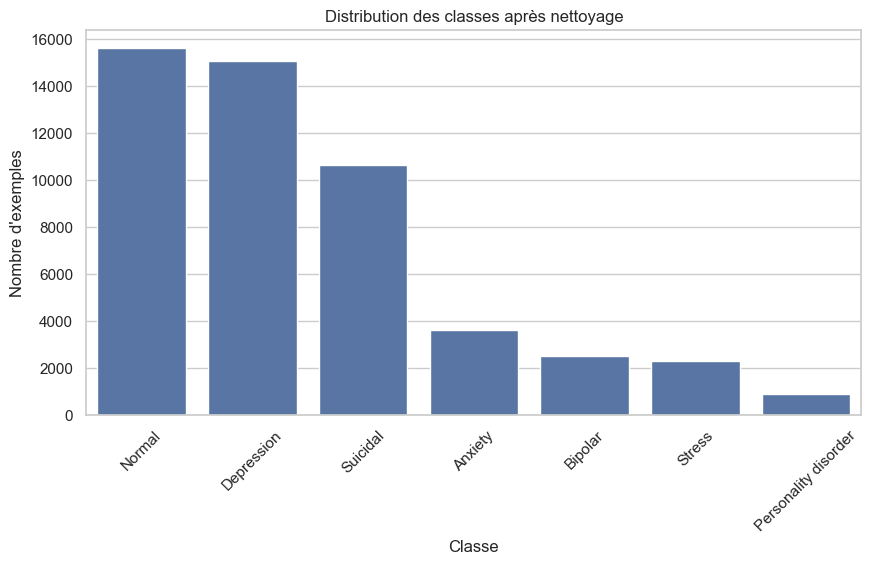

Ratio de déséquilibre après nettoyage : 17.48


In [16]:

class_counts_after = df_clean[LABEL_COL].value_counts()
class_percentages_after = df_clean[LABEL_COL].value_counts(normalize=True) * 100

class_summary_after = pd.DataFrame({
    "classe": class_counts_after.index,
    "nombre_exemples": class_counts_after.values,
    "pourcentage": class_percentages_after.values.round(2)
})

display(class_summary_after)

plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x=LABEL_COL, order=class_counts_after.index)
plt.title("Distribution des classes après nettoyage")
plt.xlabel("Classe")
plt.ylabel("Nombre d'exemples")
plt.xticks(rotation=45)
plt.show()

imbalance_ratio_after = class_counts_after.max() / class_counts_after.min()
print("Ratio de déséquilibre après nettoyage :", round(imbalance_ratio_after, 2))


## 16. Vérification des tokens les plus fréquents après nettoyage

Cette étape permet de vérifier si le nettoyage a supprimé une partie du bruit et s'il reste des mots inutiles.


,word,frequency
20,not,91462
13,just,47590
16,like,37019
7,feel,30536
26,want,27077
14,know,24327
15,life,21973
2,cannot,19083
19,no,18472
25,time,17630


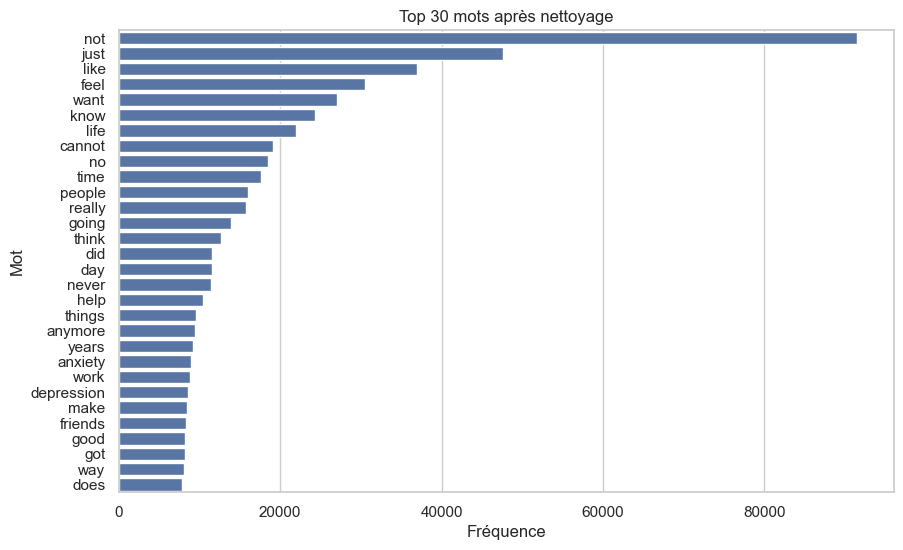

In [17]:

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=30, token_pattern=r"\b[a-zA-Z']{2,}\b")
X_counts = vectorizer.fit_transform(df_clean["clean_text"])
word_freq = np.asarray(X_counts.sum(axis=0)).ravel()
words = vectorizer.get_feature_names_out()

top_clean_words = pd.DataFrame({
    "word": words,
    "frequency": word_freq
}).sort_values(by="frequency", ascending=False)

display(top_clean_words)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_clean_words, y="word", x="frequency")
plt.title("Top 30 mots après nettoyage")
plt.xlabel("Fréquence")
plt.ylabel("Mot")
plt.show()


In [18]:
custom_stop_words = {
    "just", "like", "really", "thing", "things",
    "got", "get", "going", "make", "way",
    "day", "time", "people", "know", "think"
}

important_negations = {
    "no", "not", "never", "cannot", "can't", "dont", "don't",
    "didnt", "didn't", "won't", "wont"
}

safe_stop_words = set(safe_stop_words)
safe_stop_words = safe_stop_words.union(custom_stop_words)
safe_stop_words = safe_stop_words.difference(important_negations)

Après nettoyage, les mots les plus fréquents incluent encore des termes de négation comme “not”, “no”, “never” et “cannot”. Ces mots ont été volontairement conservés car ils portent une information sémantique essentielle dans le contexte de la santé mentale. En revanche, certains mots génériques comme “just”, “like” ou “really” peuvent être ajoutés à une liste de stopwords personnalisée afin de réduire le bruit lexical.

## 17. Exemples avant/après par classe

Cette cellule sert à vérifier qualitativement que le texte nettoyé reste compréhensible et utile.


In [19]:

for cls in df_clean[LABEL_COL].dropna().unique():
    print("\nClasse :", cls)
    display(
        df_clean.loc[df_clean[LABEL_COL] == cls, [TEXT_COL, "clean_text"]]
        .sample(min(3, len(df_clean.loc[df_clean[LABEL_COL] == cls])), random_state=42)
    )



Classe : Anxiety


,statement,clean_text
52044,A heart attack would be very obvious right? He...,heart attack obvious right? hey guys pain feel...
335,"Haven't prayed yet so restless, want to pray s...",haven't prayed restless want pray lazy astaghf...
52780,I talked my friend into doing hot yoga tonight...,talked friend doing hot yoga tonight anxiety r...



Classe : Normal


,statement,clean_text
43827,cherrytreerec oh man i can t see the vid it ot...,cherrytreerec oh man t vid ot available country
31793,open the book.,open book
36781,loves the weather and goes on a bike tour with...,loves weather goes bike tour doggy



Classe : Depression


...

,statement,clean_text
49079,Is there a way to measure how stressed I am ri...,way measure stressed right now? feel stressed ...
28393,She is very sweet and I love her immensely. I ...,sweet love immensely cannot leave currently fe...
29044,"""Fuck you bitch, I can make your life hell and...",fuck bitch make life hell kicked manage place ...



Classe : Bipolar


,statement,clean_text
46499,"depressive swing is back i’m on lamictal, lith...",depressive swing lamictal lithium abilify max ...
49863,Long Lasting Mania? I had spinal surgery last ...,long lasting mania? spinal surgery july feel l...
46780,Medications I'm wanting to talk to my doctor a...,medications wanting talk doctor going meds not...



Classe : Personality disorder


,statement,clean_text
51445,I want to be there for others But I feel so bl...,want feel blocked funny complain people unavai...
51138,the guilt of existing simply being around peop...,guilt existing simply people makes feel guilty...
51235,Trying hard not to push everyone away I’ve fou...,trying hard not push away groups school semest...


## 18. Fonction de lemmatisation optionnelle

La lemmatisation peut améliorer la cohérence des mots, mais elle peut aussi ralentir le notebook.

Pour cette raison, elle est désactivée par défaut. On pourra l'activer plus tard si les premiers modèles montrent beaucoup de sparsité lexicale.


In [20]:

if APPLY_LEMMATIZATION:
    import nltk
    nltk.download("wordnet")
    nltk.download("omw-1.4")
    from nltk.stem import WordNetLemmatizer

    lemmatizer = WordNetLemmatizer()

    def lemmatize_text(text):
        return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

    df_clean["clean_text"] = df_clean["clean_text"].apply(lemmatize_text)
    print("Lemmatisation appliquée.")
else:
    print("Lemmatisation non appliquée pour cette version initiale.")


Lemmatisation non appliquée pour cette version initiale.


La lemmatisation n’a pas été appliquée dans cette version initiale afin de conserver un preprocessing léger et rapide. Elle pourra être ajoutée ultérieurement si les premiers résultats montrent une forte sparsité lexicale.

## 19. Rapport automatique du nettoyage

Cette synthèse indique ce qui a été fait et ce qui reste important pour l'étape suivante.


In [21]:

final_rows = len(df_clean)
removed_total = initial_rows - final_rows
removed_percentage = (removed_total / initial_rows) * 100

cleaning_report = []
cleaning_report.append(f"Nombre de lignes initial : {initial_rows}")
cleaning_report.append(f"Nombre de lignes final : {final_rows}")
cleaning_report.append(f"Nombre total de lignes supprimées : {removed_total} ({round(removed_percentage, 2)}%)")
cleaning_report.append(f"Colonne texte originale conservée : {TEXT_COL}")
cleaning_report.append("Nouvelle colonne créée : clean_text")
cleaning_report.append(f"Unicode corrigé : {FIX_UNICODE}")
cleaning_report.append(f"URLs supprimées : {REMOVE_URLS}")
cleaning_report.append(f"Mentions supprimées : {REMOVE_MENTIONS}")
cleaning_report.append(f"Hashtags conservés sous forme de mots : {KEEP_HASHTAG_WORDS}")
cleaning_report.append(f"Emojis convertis en texte : {CONVERT_EMOJIS_TO_TEXT}")
cleaning_report.append(f"Slang normalisé : {NORMALIZE_SLANG}")
cleaning_report.append(f"Caractères allongés réduits : {NORMALIZE_ELONGATED_WORDS}")
cleaning_report.append(f"Ponctuation répétée réduite : {NORMALIZE_REPEATED_PUNCTUATION}")
cleaning_report.append(f"Stopwords supprimés avec conservation des négations : {REMOVE_STOPWORDS}")
cleaning_report.append(f"Ratio de déséquilibre final : {round(imbalance_ratio_after, 2)}")

print("RAPPORT AUTOMATIQUE DU DATA CLEANING")
print("=" * 60)
for item in cleaning_report:
    print("- " + item)


RAPPORT AUTOMATIQUE DU DATA CLEANING
- Nombre de lignes initial : 53043
- Nombre de lignes final : 50606
- Nombre total de lignes supprimées : 2437 (4.59%)
- Colonne texte originale conservée : statement
- Nouvelle colonne créée : clean_text
- Unicode corrigé : True
- URLs supprimées : True
- Mentions supprimées : True
- Hashtags conservés sous forme de mots : True
- Emojis convertis en texte : True
- Slang normalisé : True
- Caractères allongés réduits : True
- Ponctuation répétée réduite : True
- Stopwords supprimés avec conservation des négations : True
- Ratio de déséquilibre final : 17.48


## 20. Sauvegarde du dataset nettoyé

Le fichier obtenu sera utilisé dans l'étape suivante : **Feature Engineering & Vectorization**.


In [22]:

output_path = "mental_health_cleaned.csv"
df_clean.to_csv(output_path, index=False)

print(f"Dataset nettoyé sauvegardé dans : {output_path}")
print("Dimensions finales :", df_clean.shape)

display(df_clean[[TEXT_COL, "clean_text", LABEL_COL]].head())


Dataset nettoyé sauvegardé dans : mental_health_cleaned.csv
Dimensions finales : (50606, 8)


,statement,clean_text,status
0,oh my gosh,oh gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...,Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",wrong dear forward doubt stay restless restles...,Anxiety
3,I've shifted my focus to something else but I'...,shifted focus worried,Anxiety
4,"I'm restless and restless, it's been a month n...",restless restless month boy mean?,Anxiety


# Décisions finales pour passer à l'étape suivante

À partir de ce nettoyage, la prochaine étape sera :

## Step 03 — Feature Engineering & Vectorization

On pourra comparer :

- TF-IDF unigram ;
- TF-IDF n-grams ;
- CountVectorizer baseline ;
- Word2Vec moyen par phrase ;
- éventuellement embeddings plus avancés dans une phase ultérieure.

## Points à retenir pour la modélisation

- Le dataset reste déséquilibré : il faudra utiliser `class_weight`, `macro F1`, et un split stratifié.
- La colonne `clean_text` devient l'entrée principale des modèles.
- Les textes originaux restent conservés pour l'analyse d'erreurs.
- Les emojis ont été transformés plutôt que supprimés, car ils portent une information émotionnelle.
- Les négations ont été conservées, car elles changent fortement le sens psychologique du texte.
